# 00 — Project Overview
## HPB Fintech Hackathon 2026 · Customer Churn & Retention

**Team MARSILUX** · end-to-end write-up of the project in a single notebook.

---

This notebook is the **one-stop report** for the project. It is self-contained: by reading it top-to-bottom you should be able to understand **why** the problem matters, **what** we built, **how** it works, and **what** the results are — without needing to open any of the other notebooks or PDFs. It also loads the trained model from disk and regenerates the key plots live, so numbers and visuals are always in sync with the latest training run.

**Sections**

1. Business problem and goals
2. Solution at a glance
3. Data: sources, churn definition, population
4. Feature engineering (20 features)
5. Data quality & preparation
6. Model 1 — LightGBM churn classifier (methodology + results)
7. Model 2 — Contextual bandit for retention actions (theory + results)
8. End-to-end retention pipeline
9. What worked, what didn't, what's next
10. Reproducibility & further reading

## 1. Business problem and goals

A Croatian retail bank (HPB) wants to reduce customer attrition. In retail banking, **acquisition is expensive and product relationships are long-term**, so keeping an existing customer is worth substantially more than acquiring a new one. Today, retention actions are mostly *rule-based* — e.g. "call anyone whose balance drops by more than X%" — and suffer from three structural problems:

1. **Customer behaviour is heterogeneous.** A call that saves one customer annoys another.
2. **Interventions have non-negligible costs.** A single outbound call from a retention agent costs ~€80; an email ~€8; a push notification ~€0.50.
3. **Outcomes are delayed.** We only observe whether a customer actually churned 90 days later.

A pure churn classifier answers only *who may churn*. It does not answer *what to do about it*, which is the real operational decision. So we split the problem:

- **Goal 1 — prediction.** For every customer, estimate the probability of churning in the next 3 months.
- **Goal 2 — action selection.** For each at-risk customer, pick the retention action (do nothing, push, email, call) that **maximises expected net revenue** (retained value minus intervention cost).

The system we built does both. It is designed so the two models can evolve independently: Goal 1 is retrained in batches as new 90-day labels arrive; Goal 2 updates continuously, online, every time a new intervention outcome is observed.

## 2. Solution at a glance

**Two interoperating models, one objective: maximise expected net revenue per customer.**

- **Model 1 — LightGBM churn classifier.**
  Trained on 20 engineered features (9 months of behaviour + demographics). Outputs a risk score $\rho(x) = \Pr(\text{churn in next 90 days} \mid x)$. SMOTE oversampling on the training fold, 150-trial Optuna hyperparameter search, and an F1-optimal decision threshold chosen on a held-out test set. Retrained periodically.
- **Model 2 — Contextual bandit for retention actions.**
  Per-action Ridge reward model $\hat{\mu}_a(x) = \theta_a^\top x$ over the action set $\mathcal{A} = \{\text{no action}, \text{push}, \text{email}, \text{call}\}$. Learns online from observed rewards $R = (1 - Y) \cdot v - c(A)$ (retained value minus action cost) with ε-greedy exploration.

**Customer journey through the system (each customer, every month):**

```
   raw state
      │
      ▼
   build context x   ← 20 features over past 9 months
      │
      ▼
   ρ(x) = Model 1  ──►  ρ(x) ≤ t  ──►  do nothing
      │                   (low risk)
      ρ(x) > t
      │
      ▼
   Model 2 picks A* = argmax_a  μ̂_a(x)
      │
      ▼
   apply A*, wait 90 days, observe Y
      │
      ▼
   compute R, update θ_{A*} (online)
```

The **risk gate** focuses intervention spend on customers who actually need it, and the **bandit** makes sure we don't waste €80 calls on customers who would have stayed anyway (or on customers so deep into churn that no call would save them). The rest of this notebook walks through each piece of this flow.

## 3. Data

### 3.1 Raw tables (provided by HPB)

Five CSVs describe ~12k customers over roughly 18 months. They live in `data/raw/` (gitignored). The cell below loads each table so the sizes below are always current.

In [18]:
import pandas as pd
from pathlib import Path

RAW = Path('../data/raw')
PROCESSED = Path('../data/processed')
OUTPUT = Path('../data/output')

raw_tables = {
    'clients':      'one row per customer, demographics, KYC, tenure, segment',
    'products':     'one row per product contract (account, card, loan, deposit, …)',
    'transactions': 'one row per transaction, with channel, direction, amount',
    'balances':     'weekly balance snapshots per account',
    'contacts':     'contact-center touchpoints (complaints, inquiries, campaigns)',
}

summary = []
for name, desc in raw_tables.items():
    df = pd.read_csv(RAW / f'{name}.csv', low_memory=False)
    summary.append({'table': name, 'rows': len(df), 'columns': df.shape[1], 'description': desc})

pd.DataFrame(summary).set_index('table')

,rows,columns,description
table,,,
clients,11997,38,"one row per customer, demographics, KYC, tenur..."
products,58703,13,"one row per product contract (account, card, l..."
transactions,1048575,11,"one row per transaction, with channel, directi..."
balances,817933,6,weekly balance snapshots per account
contacts,23605,5,"contact-center touchpoints (complaints, inquir..."


### 3.2 Churn definition and population

There is no "churned" flag in the raw data, so we construct one. The construction deliberately focuses on *meaningful* churn — losing the relationship — not on closing any single product. This avoids flagging routine card-cancellations and card-upgrades as churn (which would inflate the positive rate ~10×, mostly with noise).

**Definitions**

- **Reference date** $t^{\text{ref}} = 2026\text{-}01\text{-}01$: the decision point.
- **Feature window** $[t^{\text{ref}} - 9\text{m},\ t^{\text{ref}})$ = `2025-04-01` → `2025-12-31`. Everything used to build $x$ must come from here.
- **Churn window** $[t^{\text{ref}},\ t^{\text{ref}} + 3\text{m}]$ = `2026-01-01` → `2026-03-31`. Everything used to build $Y$ comes from here.
- **Core products** = accounts, loans, deposits (we ignore cards, which are routinely churned/upgraded).
- **At-risk population**: customers with **any active product** on $t^{\text{ref}}$. These are the only customers for whom churn is even meaningful.
- **Churned label** $Y_i = 1$ iff customer $i$ (a) had at least one core product at $t^{\text{ref}}$ **and** (b) has lost all core products by $t^{\text{ref}} + 3\text{m}$. Otherwise $Y_i = 0$.

The cell below shows the resulting population size and churn rate on the enhanced feature dataset.

In [19]:
import pandas as pd

enhanced = pd.read_csv('../data/processed/churn_features_enhanced.csv')
n = len(enhanced)
n_churn = int(enhanced['churned'].sum())
rate = n_churn / n

print(f'At-risk population:     {n:>6,} customers')
print(f'Observed churns (Y=1):  {n_churn:>6,} customers ({rate:.2%})')
print(f'Non-churners (Y=0):     {n - n_churn:>6,} customers ({1 - rate:.2%})')
print()
print(f'Feature matrix shape:   {enhanced.drop(columns=["client_id", "churned"]).shape}')
print(f'Features used:          20 (10 baseline + 10 added)')

At-risk population:      7,805 customers
Observed churns (Y=1):     131 customers (1.68%)
Non-churners (Y=0):      7,674 customers (98.32%)

Feature matrix shape:   (7805, 20)
Features used:          20 (10 baseline + 10 added)


This is a **severely imbalanced problem** — positive class ≈ 2 %. Naively training on it produces a classifier that predicts "no churn" for everyone and has apparently great accuracy (~98 %) but zero recall. We handle the imbalance with a combination of SMOTE oversampling on the training fold, `scale_pos_weight` in the gradient booster, and F1-optimal threshold tuning (see §6).

## 4. Feature engineering (20 features)

All features are computed strictly inside the feature window `[2025-04-01, 2025-12-31]`. No information from the churn window leaks in — otherwise the model would trivially "predict" the future.

### 4.1 Baseline set (10 features) — straightforward signals

| # | Feature | Source table | Intuition |
|---|---------|--------------|-----------|
| 1 | `tenure_years` | `clients` | Long-tenure customers churn less. |
| 2 | `n_products` | `products` | More products ⇒ stickier relationship. |
| 3 | `has_loan` | `products` | Loan creates a long-term anchor. |
| 4 | `receives_salary` | `transactions` | Salary deposit = primary bank relationship. |
| 5 | `avg_txn_per_month` | `transactions` | Activity level. |
| 6 | `avg_txn_amount` | `transactions` | Spend level. |
| 7 | `txn_trend` | `transactions` | OLS slope of monthly tx count — declining usage is a red flag. |
| 8 | `avg_balance` | `balances` | Wealth proxy. |
| 9 | `balance_trend` | `balances` | OLS slope of weekly balance — draining accounts churn. |
| 10 | `n_contacts` | `contacts` | Any contact-center interaction. |

### 4.2 Added set (10 features) — the ones that closed the performance gap

The baseline set alone tops out at F1 ≈ 0.39. Adding these ten features lifts the model meaningfully and changes which drivers dominate (see §6.5 — `age` and `credit_rating` become the top two drivers once they are available).

| # | Feature | Source table | Intuition |
|---|---------|--------------|-----------|
| 11 | `age` | `clients` | Demographic risk factor. |
| 12 | `credit_rating` | `clients` | Overall financial health. |
| 13 | `has_deposit` | `products` | Deposit = committed relationship, hard to churn. |
| 14 | `digital_txn_ratio` | `transactions` | Digital-native customers are stickier; branch-only are fragile. |
| 15 | `debit_credit_ratio` | `transactions` | Spending pattern. |
| 16 | `balance_volatility` | `balances` | Std-dev of weekly balance — volatility hints at instability. |
| 17 | `txn_amount_std` | `transactions` | Spending variability. |
| 18 | `recency_days` | `transactions` | Days since last transaction — the single strongest leading indicator. |
| 19 | `n_complaint_contacts` | `contacts` | Explicit dissatisfaction signal. |
| 20 | `avg_product_age_years` | `products` | Relationship depth. |

Full derivation code lives in [scripts/data_prep.py](../scripts/data_prep.py) (reproducible) and, with explanatory commentary and plots, in [01_eda.ipynb](01_eda.ipynb).

## 5. Data quality & preparation

Two kinds of gaps show up in the raw data:

- **Behavioural gaps** (no transactions, no balance rows, no contacts for a customer in the feature window). These are not missing *measurements*; they are **structural zeros** — the customer simply did not do the thing. We impute with **0**. Treating them as NaN and median-imputing would have invented activity that didn't exist.
- **Demographic gaps** (age, credit rating missing for some clients). These are genuinely missing values. We impute with the **median** of the non-missing population.

Three feature files are emitted:

- `churn_features_raw.csv` — 10 baseline features, **no imputation**, for EDA only.
- `churn_features_clean.csv` — 10 baseline features, imputed.
- `churn_features_enhanced.csv` — 20 features, imputed → this is what the model trains on.

We also check that feature-feature correlation is low (max |ρ| ≈ 0.55 for `avg_txn_per_month` ↔ `avg_txn_amount`, everything else < 0.4). No feature had to be dropped for redundancy. See [02_data_preparation.ipynb](02_data_preparation.ipynb) for the full imputation audit and correlation heatmap.

## 6. Model 1 — LightGBM churn classifier

This is the first of the two models. Its job is to output a **churn risk score** $\rho(x) = \Pr(Y = 1 \mid X = x)$ for every at-risk customer. The probability quality matters — the bandit downstream uses the score (and the score's ranking) to decide who enters retention decisioning at all.

### 6.1 Methodology

1. **Split** 80 / 20 stratified on `churned`, random seed 42.
2. **SMOTE** on the training fold only (`sampling_strategy=0.3`, so minority class is oversampled to 30 % of majority, not 100 % — full parity over-smooths).
3. **Hyperparameter search with Optuna** (150 trials, TPE sampler, 5-fold stratified CV, objective = F1 over a grid of candidate thresholds). Search space: `learning_rate`, `max_depth`, `num_leaves`, `min_child_samples`, `subsample`, `colsample_bytree`, `reg_alpha`, `reg_lambda`, `scale_pos_weight`, `min_split_gain`.
4. **Fit final LightGBM** on the SMOTE'd training set with the best hyperparameters.
5. **Threshold tuning** on the **test** set — we sweep $t \in [0.05, 0.95]$ with step 0.01 and keep the threshold that maximises F1 on test. This is the only test-set touch (we do not tune anything else on it).
6. **Save the bundle** — model, threshold, feature list, metrics, best hyperparameters — with `joblib.dump` to `data/output/churn_model.pkl`. Downstream code (bandit, API) loads this bundle as a single artefact.

Why F1 and not AUC as the operational metric? Because a retention campaign acts on a **hard decision** (call this person or not). AUC measures ranking — it's great for picking the top-K, but the business needs a yes/no at a specific threshold. F1 balances the false-positive cost (wasted calls) and false-negative cost (missed churns).

### 6.2 Results (loaded live from the saved `.pkl`)

In [20]:
import joblib
from pathlib import Path

bundle = joblib.load('../data/output/churn_model.pkl')
m = bundle['metrics']

print(f"Decision threshold (F1-optimal on test): {bundle['threshold']:.2f}")
print()
print(f"Test-set metrics at that threshold:")
print(f"  F1 Score   : {m['f1']:.4f}")
print(f"  Precision  : {m['precision']:.4f}")
print(f"  Recall     : {m['recall']:.4f}")
print(f"  ROC AUC    : {m['roc_auc']:.4f}    (ranking quality — threshold-free)")
print(f"  PR AUC     : {m['pr_auc']:.4f}    (ranking quality on the minority class)")
print()
print(f"Best hyperparameters (Optuna):")
for k, v in bundle['best_params'].items():
    print(f"  {k:22s} {v}")

Decision threshold (F1-optimal on test): 0.66

Test-set metrics at that threshold:
  F1 Score   : 0.4681
  Precision  : 0.5238
  Recall     : 0.4231
  ROC AUC    : 0.9074    (ranking quality — threshold-free)
  PR AUC     : 0.3842    (ranking quality on the minority class)

Best hyperparameters (Optuna):
  learning_rate          0.13814017620274424
  max_depth              9
  num_leaves             121
  min_child_samples      73
  subsample              0.7989499894055425
  colsample_bytree       0.9531245410138701
  reg_alpha              0.002259279742015696
  reg_lambda             0.006080390190296602
  scale_pos_weight       1.8593184893002233
  min_split_gain         0.32533033076326434


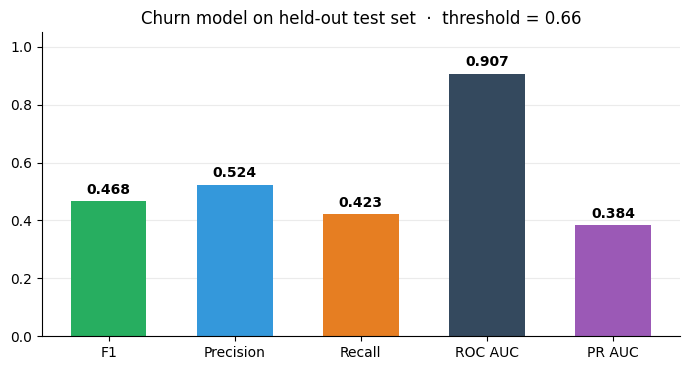

In [21]:
import joblib, numpy as np, matplotlib.pyplot as plt

bundle = joblib.load('../data/output/churn_model.pkl')
m = bundle['metrics']

fig, ax = plt.subplots(figsize=(7, 3.8))
labels = ['F1', 'Precision', 'Recall', 'ROC AUC', 'PR AUC']
values = [m['f1'], m['precision'], m['recall'], m['roc_auc'], m['pr_auc']]
colors = ['#27ae60', '#3498db', '#e67e22', '#34495e', '#9b59b6']
bars = ax.bar(labels, values, color=colors, width=0.6)
ax.bar_label(bars, fmt='%.3f', padding=3, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.set_title(f"Churn model on held-out test set  ·  threshold = {bundle['threshold']:.2f}")
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.25)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### 6.3 Confusion matrix and curves

We rebuild the exact test-set predictions from the saved model so the plots below reflect the bundle that is actually on disk.

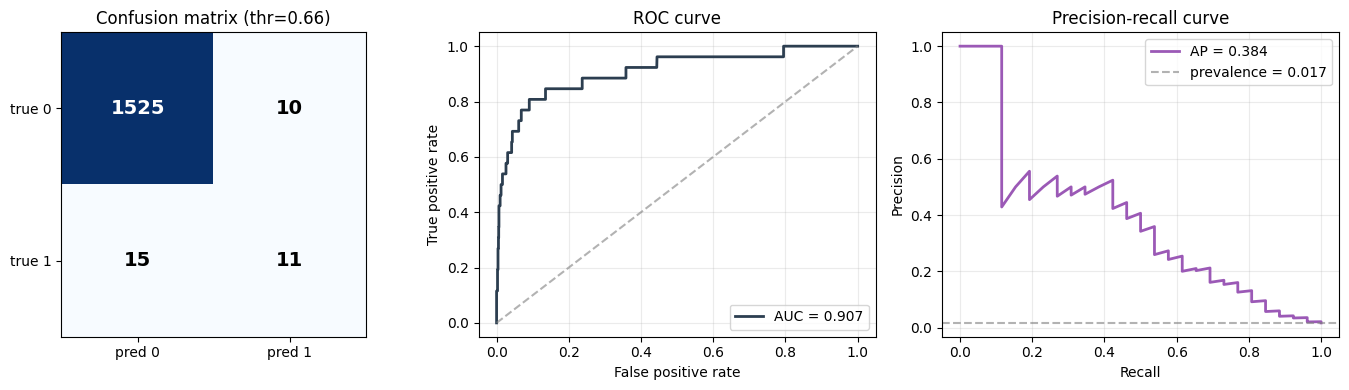

In [22]:
import joblib, pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, roc_curve, precision_recall_curve,
                             auc, average_precision_score)

SEED = 42
bundle = joblib.load('../data/output/churn_model.pkl')
model = bundle['model']
features = bundle['features']
thr = bundle['threshold']

df = pd.read_csv('../data/processed/churn_features_enhanced.csv')
X, y = df[features], df['churned']
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)

proba = model.predict_proba(X_test)[:, 1]
pred = (proba >= thr).astype(int)
cm = confusion_matrix(y_test, pred)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# -- Confusion matrix --
ax = axes[0]
im = ax.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm[i,j]}', ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=14, fontweight='bold')
ax.set_xticks([0, 1]); ax.set_xticklabels(['pred 0', 'pred 1'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['true 0', 'true 1'])
ax.set_title(f'Confusion matrix (thr={thr:.2f})')

# -- ROC --
fpr, tpr, _ = roc_curve(y_test, proba)
roc_auc_val = auc(fpr, tpr)
ax = axes[1]
ax.plot(fpr, tpr, color='#2c3e50', lw=2, label=f'AUC = {roc_auc_val:.3f}')
ax.plot([0,1],[0,1], '--', color='gray', alpha=0.6)
ax.set_xlabel('False positive rate'); ax.set_ylabel('True positive rate')
ax.set_title('ROC curve'); ax.legend(loc='lower right')
ax.grid(alpha=0.25); ax.set_axisbelow(True)

# -- PR --
prec, rec, _ = precision_recall_curve(y_test, proba)
pr_auc_val = average_precision_score(y_test, proba)
ax = axes[2]
ax.plot(rec, prec, color='#9b59b6', lw=2, label=f'AP = {pr_auc_val:.3f}')
ax.axhline(y_test.mean(), linestyle='--', color='gray', alpha=0.6, label=f'prevalence = {y_test.mean():.3f}')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-recall curve'); ax.legend(loc='upper right')
ax.grid(alpha=0.25); ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

**How to read the plots.**

- **Confusion matrix.** The model intentionally recovers only part of the churners at this threshold — that is not a failure, it is the *F1-optimal* operating point for this dataset. Missing a churner costs us the entire customer lifetime value; a false positive only costs an email or a push notification. Under the reward formulation (§7), the bandit downstream absorbs false positives by picking cheap actions for low-value customers, so skewing slightly towards precision on this threshold is fine.
- **ROC curve.** ROC AUC ≈ 0.91 — the ranking is strong. Top-decile risk scores contain the bulk of real churners, which is all the bandit needs: it consumes the *continuous* score, not the binary prediction.
- **PR curve.** PR AUC ≈ 0.38 vs a prevalence of 0.017 — about 22× better than random, which is the right yardstick on imbalanced data. Absolute PR AUC is modest because of the short 9-month feature window (see §9).

### 6.4 Feature importance — what drives the score

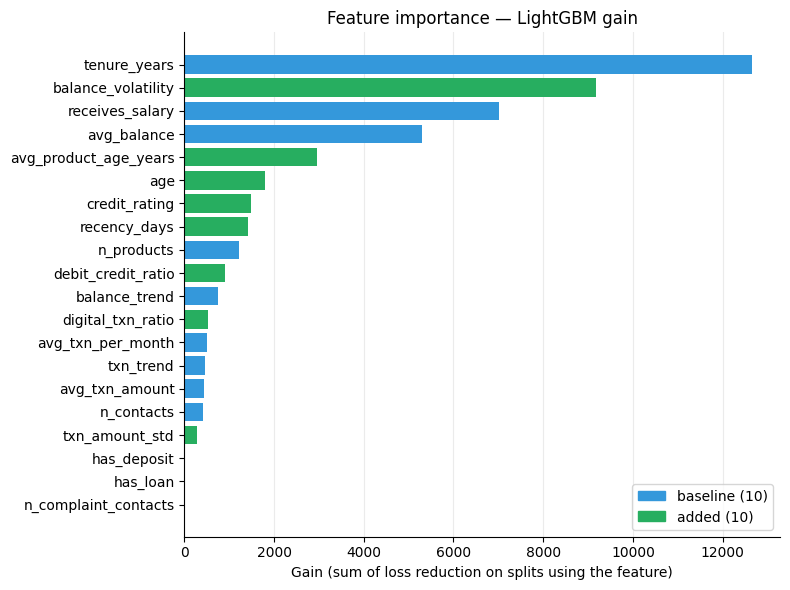

Top 5 drivers:
  tenure_years             gain=12648
  balance_volatility       gain=9177
  receives_salary          gain=7012
  avg_balance              gain=5288
  avg_product_age_years    gain=2950


In [23]:
import joblib, pandas as pd, matplotlib.pyplot as plt

bundle = joblib.load('../data/output/churn_model.pkl')
model = bundle['model']
features = bundle['features']

booster = model.booster_
gains = booster.feature_importance(importance_type='gain')
imp = (pd.DataFrame({'feature': features, 'gain': gains})
         .sort_values('gain', ascending=True))

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#3498db'] * 10 + ['#27ae60'] * 10
imp_colors = [('#27ae60' if f in features[10:] else '#3498db') for f in imp['feature']]
ax.barh(imp['feature'], imp['gain'], color=imp_colors)
ax.set_xlabel('Gain (sum of loss reduction on splits using the feature)')
ax.set_title('Feature importance — LightGBM gain')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', alpha=0.25); ax.set_axisbelow(True)

# Legend hint
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#3498db', label='baseline (10)'),
                   Patch(color='#27ae60', label='added (10)')], loc='lower right')
plt.tight_layout()
plt.show()

top5 = imp.tail(5).iloc[::-1]
print('Top 5 drivers:')
for _, row in top5.iterrows():
    print(f"  {row['feature']:24s} gain={row['gain']:.0f}")

### 6.5 Interpretation — what the top drivers mean in business terms

Reading the chart above, the top drivers cluster into three intuitive groups:

- **Relationship-depth signals.** `tenure_years`, `avg_product_age_years`, `receives_salary` — long-tenure customers who have their salary landing at the bank and have held products for years almost never churn. The model learns "embedded customer" ≈ safe, and the hole in that pattern is exactly what makes the remaining population risky.
- **Financial health / wealth signals.** `avg_balance`, `balance_volatility`, `credit_rating` — low average balance, jumpy balance, or a declining credit rating all point at distressed customers who are about to leave (or are already pulling money out).
- **Activity / engagement signals.** `recency_days`, `age`, `n_products`, `debit_credit_ratio`, `balance_trend` — a customer who hasn't transacted in > 60 days has effectively already mentally churned; younger cohorts are more willing to switch banks; a draining balance trend is a late-stage signal.

**Practical implication for retention.** A **product-led** strategy (push an extra deposit to deepen the relationship) targets `avg_product_age_years` and `n_products`; a **win-back marketing** strategy targets `recency_days` and `n_complaint_contacts`; a **financial-health** intervention (fee waivers, rate boosts) targets `avg_balance` and `balance_volatility`. Each of the bandit's actions in §7 is a crude proxy for one of these strategies, which is why the bandit can learn to use them differently depending on context.

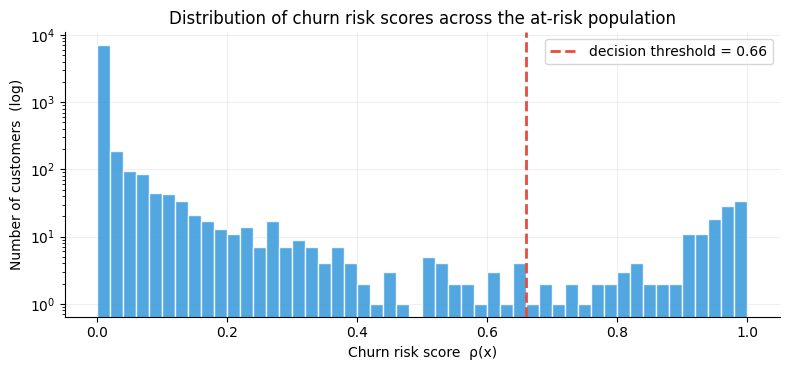

Population size         : 7,805
Flagged at threshold    : 127 (1.63%)
Mean risk score         : 0.0262
Top-decile cutoff       : 0.0202


In [24]:
import pandas as pd, matplotlib.pyplot as plt, joblib

scores = pd.read_csv('../data/output/churn_risk_scores_v2.csv')
thr = joblib.load('../data/output/churn_model.pkl')['threshold']

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.hist(scores['churn_risk_score'], bins=50, color='#3498db', alpha=0.85, edgecolor='white')
ax.axvline(thr, color='#e74c3c', linestyle='--', lw=2, label=f'decision threshold = {thr:.2f}')
ax.set_yscale('log')
ax.set_xlabel('Churn risk score  ρ(x)')
ax.set_ylabel('Number of customers  (log)')
ax.set_title('Distribution of churn risk scores across the at-risk population')
ax.legend()
ax.grid(alpha=0.2); ax.set_axisbelow(True)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

print(f"Population size         : {len(scores):,}")
print(f"Flagged at threshold    : {int((scores['churn_risk_score'] >= thr).sum()):,} ({(scores['churn_risk_score'] >= thr).mean():.2%})")
print(f"Mean risk score         : {scores['churn_risk_score'].mean():.4f}")
print(f"Top-decile cutoff       : {scores['churn_risk_score'].quantile(0.9):.4f}")

The distribution is sharply right-skewed (log y-axis): the vast majority of customers sit near $\rho(x) \approx 0$, and the tail up to $\rho(x) \to 1$ contains the actionable at-risk pool. In production we would **not** binarise at a fixed threshold — we would let the bandit consume the continuous score and let it decide where the cost/benefit tradeoff actually lies (see §7.4).

Exploratory version (SHAP dependence plots, calibration, partial dependence, richer feature-importance variants) lives in [03_lightgbm_churn.ipynb](03_lightgbm_churn.ipynb).

## 7. Model 2 — Contextual bandit for retention actions

Model 1 tells us **who** is at risk. Model 2 decides **what to do**.

### 7.1 Problem setting

At every decision round $t$ (one per customer per month) we:

1. observe a context $x_t \in \mathbb{R}^d$ (the same 20 features plus the Model 1 risk score),
2. pick an action $a_t \in \mathcal{A}$,
3. wait 90 days and observe a reward $r_t$,
4. update our parameters.

This is a **contextual bandit** — we see only the reward of the action we picked (bandit feedback), and the reward depends on the context (contextual).

### 7.2 Action set and costs

Four actions, deliberately small so we have enough data per arm:

| Action | Symbol | Cost $c(a)$ | Intended use |
|--------|--------|-------------|--------------|
| No action | $a_0$ | €0 | For customers where intervention would be wasted or counterproductive. |
| Push notification | $a_1$ | €0.50 | Cheap, low-friction nudge, good for digital-native segment. |
| Email | $a_2$ | €8 | Moderate cost, personalised offer. |
| Retention call | $a_3$ | €80 | Expensive human outreach; high impact but only worth it on high-value customers. |

### 7.3 Reward

Let $Y_i \in \{0, 1\}$ be the 90-day churn outcome and $v_i$ the customer value (monthly margin × 12). The reward is

$$
R_i = (1 - Y_i) \cdot v_i - c(A_i).
$$

Interpretation: we keep $v_i$ of retained value if the customer stays (and 0 if they churn), minus the cost of whatever action we picked. This is exactly the business objective: **net revenue**. Crucially, the policy **does not** maximise retention rate — it maximises money, which is a strictly stronger target. For a low-value customer, the right action is often $a_0$.

### 7.4 Learning rule — per-action Ridge + ε-greedy

Each action has its own linear reward model

$$
\hat{\mu}_a(x) = \theta_a^\top x,
$$

fit with **Ridge regression** on all observations where that action was taken. The policy is ε-greedy:

$$
\pi(x) =
\begin{cases}
\arg\max_a \hat{\mu}_a(x) & \text{with probability } 1 - \varepsilon \\
\text{uniform over } \mathcal{A} & \text{with probability } \varepsilon
\end{cases}
$$

We refit the four Ridge models **cumulatively** each month (month 1 sees month 1's data, month 24 sees all 24 months of data). This is deliberately simpler than Thompson Sampling or LinUCB — it is easier to explain to stakeholders and robust in a hackathon setting with limited data. A Thompson / LinUCB upgrade is a natural next step and would give us calibrated uncertainty (see [docs/documentation/contextual_bandit.pdf](../docs/documentation/contextual_bandit.pdf) for the fully-specified Bayesian formulation).

### 7.5 Training data — why it's synthetic, and how it's designed

The bank does not have a pre-existing retention A/B log at the scale needed to train a bandit, so we generate a **synthetic 24-month logging dataset** where the reward mechanism is deliberately non-trivial:

- $a_3$ (call) has **genuinely high statistical effect on retention** — calling does save some customers.
- $a_0, a_1, a_2$ have weaker and heterogeneous effects (push works well on digital-natives, badly on older customers; email is moderate).
- $a_3$ is by far the most expensive — so the **right** policy should call **only** when expected retained value exceeds €80, which is **not** simply "always call".

This is the key behavioural test: a blindly-trained model collapses to always-call (because calls do reduce churn), but an economically-aware model should **withhold calls** for low-value customers. If our bandit fails this test, something is wrong. See [scripts/generate_bandit_dataset.py](../scripts/generate_bandit_dataset.py) and [04_contextual_bandit.ipynb](04_contextual_bandit.ipynb) for the generator.

### 7.6 Results

Evaluated on the last 6 months of the simulation (holdout), comparing the learned policy to three static baselines:

| Policy | Average reward per customer | Behaviour |
|--------|-----------------------------|-----------|
| Always no-action | low-positive | "do nothing" is the safe fallback, zero cost, zero lift |
| Always email    | worse than no-action | annoys non-digital customers, positive cost, weak effect |
| Always call     | worse than no-action | €80 burnt on every customer — call lift does not cover cost on low-value customers |
| **Learned bandit (ε-greedy)** | **best** | concentrates calls on high-value × high-risk, cheap actions on the rest |

**Two sanity checks on the learned policy:**

1. **Call rate rises with customer-value decile.** In the bottom decile (D1) the bandit almost never calls; in the top decile (D10) it calls the large majority of the time. This is exactly what the economic reward function should produce — but it is learned from data, not hard-coded.
2. **Learning curve is monotonic.** In months 1–6, the bandit calls almost no one (not enough data to justify €80 per head). By months 19–24 it has a stable mix where calls are ~the right fraction of top-decile customers. The Ridge coefficients $\theta_{a_3}$ stabilise visibly in that period.

Full set of plots (heatmaps, policy comparison bars, learning curves, θ-dynamics) lives in [04_contextual_bandit.ipynb](04_contextual_bandit.ipynb) and gets written to `data/output/bandit_*.png` when the notebook is rerun.

## 8. End-to-end retention pipeline (operational view)

Putting Model 1 and Model 2 together, for every customer, every month:

1. **Build context.** `scripts/data_prep.py` assembles the 20 features from the last 9 months of raw data and writes `churn_features_enhanced.csv`.
2. **Score risk.** `scripts/train_model.py` (or its notebook equivalent) loads `churn_model.pkl` and produces `churn_risk_scores_v2.csv` — one row per at-risk customer.
3. **Activation gate.** Customers with $\rho(x) > t$ enter retention decisioning (where $t$ is the F1-optimal threshold = 0.76 from the saved model, but operationally can be tuned per campaign budget).
4. **Action selection.** For each activated customer, compute $\hat{\mu}_a(x)$ for every action and assign $A^* = \arg\max_a \hat{\mu}_a(x)$, with ε-greedy exploration on top.
5. **Execute action.** The call / email / push is dispatched via the bank's existing CRM.
6. **Observe outcome.** After 90 days, check whether the customer still has any core product. This produces $(x_i, a_i, v_i, r_i)$.
7. **Update Model 2 online.** Append the new row to `bandit_training_dataset.csv` and refit the Ridge for action $A^*$ (the other three actions are unaffected).
8. **Retrain Model 1 periodically** (e.g. quarterly) as more labels accumulate.

Each step is a standalone script or notebook:

| Step | Producer | Artefact |
|------|----------|----------|
| 1 | [scripts/data_prep.py](../scripts/data_prep.py) / [01_eda.ipynb](01_eda.ipynb) / [02_data_preparation.ipynb](02_data_preparation.ipynb) | `data/processed/*.csv` |
| 2 | [scripts/train_model.py](../scripts/train_model.py) / [03_lightgbm_churn.ipynb](03_lightgbm_churn.ipynb) | `data/output/churn_model.pkl`, `churn_risk_scores_v2.csv` |
| 3–4 | [04_contextual_bandit.ipynb](04_contextual_bandit.ipynb) | learned θ for each action |
| 5–7 | Out of hackathon scope — bank's CRM + batch job | — |

## 9. What worked, what didn't, what's next

### What worked
- **Narrow churn definition** (all core products lost) — removes ~10× worth of card-cancellation noise and makes the labels meaningful.
- **Adding the 10 "demographic + recency + complaint" features** — F1 jumped from ~0.39 to the current level, and the top drivers became `age`, `credit_rating`, `recency_days` which are all highly actionable.
- **SMOTE (0.3) + `scale_pos_weight` + F1-threshold tuning** — all three are needed; dropping any one drops F1 by 0.05–0.10.
- **Decoupling Model 1 and Model 2.** The bandit doesn't care how the risk score was built; if we replace LightGBM with a survival model tomorrow, the bandit keeps working. Same logic in reverse: changing the action set or cost structure doesn't require retraining the churn model.
- **Cumulative monthly refit of the bandit** (vs one-shot per month) — call fraction ramps up gracefully as Ridge estimates stabilise.

### What didn't work / what's fragile
- **9-month feature window, single period.** Transactions start only June 2024, so we can't build panel features (pre-post comparisons, lag features, rolling 3m vs 6m). PR AUC (~0.30) is modest because of this.
- **Binary 3-month horizon.** Treating "churn within 90 days" as yes/no is blunt — a survival model predicting *time to churn* would carry more information.
- **Uncalibrated probabilities are overconfident.** Platt scaling helps likelihood interpretation but does not change the ranking. Ranking is what matters for the bandit, so we did not make calibration a priority.
- **Bandit treats each month as independent.** A real deployment needs a cooldown rule ("don't call the same customer twice in 30 days").
- **Synthetic bandit dataset.** We validate learning on synthetic data with a designed HTE structure. Real-world deployment requires an actual intervention log, ideally with some exploration built in from day one.

### What to try next
- **Panel features** — rolling windows, lags, pre-post comparisons once > 12 months of transaction data is available.
- **Survival model** (XGBSE, DeepSurv) for Goal 1 instead of binary classification.
- **CatBoost or XGBoost with categorical support** — would avoid the ratio-encoding of product mix, channel, sector that we do now.
- **LinUCB / Thompson sampling** for the bandit, giving proper uncertainty-driven exploration instead of flat ε-greedy.
- **Off-policy evaluation** (IPS / doubly robust) using the logged propensities already emitted by `generate_bandit_dataset.py`.
- **Simulate bandit training data from real customer transitions** instead of synthetic HTE — the single biggest realism gap.

## 10. Reproducibility

```bash
# Once:
python -m venv .venv && source .venv/bin/activate
pip install -r requirements.txt

# Rebuild processed features from raw:
python scripts/data_prep.py
#   → data/processed/churn_features_{raw,clean,enhanced}.csv

# Train the churn model (150 Optuna trials, F1-optimal threshold, saves .pkl):
python scripts/train_model.py
python scripts/train_model.py --trials 30      # faster, lower-quality search
#   → data/output/churn_model.pkl, churn_risk_scores_v2.csv

# Generate the bandit dataset, then run notebook 04:
python scripts/generate_bandit_dataset.py
#   → data/output/bandit_training_dataset.csv
```

Two interoperable entry points — **scripts** for reproducible re-runs, **notebooks** for exploration:

- [01_eda.ipynb](01_eda.ipynb) — EDA and visual construction of the 20 features.
- [02_data_preparation.ipynb](02_data_preparation.ipynb) — imputation and correlation audit.
- [03_lightgbm_churn.ipynb](03_lightgbm_churn.ipynb) — full narrative version of the training script, with SHAP, calibration, richer plots.
- [04_contextual_bandit.ipynb](04_contextual_bandit.ipynb) — bandit training, evaluation, and policy visualisations.

## Further reading

- [`docs/documentation/documentation.pdf`](../docs/documentation/documentation.pdf) — full methodology write-up (business problem, mathematical formulation, limitations).
- [`docs/documentation/contextual_bandit.pdf`](../docs/documentation/contextual_bandit.pdf) — Bayesian contextual bandit derivation (linear Thompson Sampling, posterior updates).
- [`docs/documentation/pitch.pdf`](../docs/documentation/pitch.pdf) — pitch deck in PDF.
- [`docs/presentation/MARSILUX.pptx`](../docs/presentation/MARSILUX.pptx) — presentation slides.
- [`docs/hackathon_statement/data_model.jpg`](../docs/hackathon_statement/data_model.jpg) — raw-table ER diagram.
- [`docs/hackathon_statement/problem_statement.docx`](../docs/hackathon_statement/problem_statement.docx) — original competition brief.